## Решение задачи регрессии: предсказать Y координату по X координате точки

## 1. Импорт библиотек

In [385]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

## 2. Создание и визуализация датасета

Создадим искусственный датасет из восьми классов точек на плоскости:

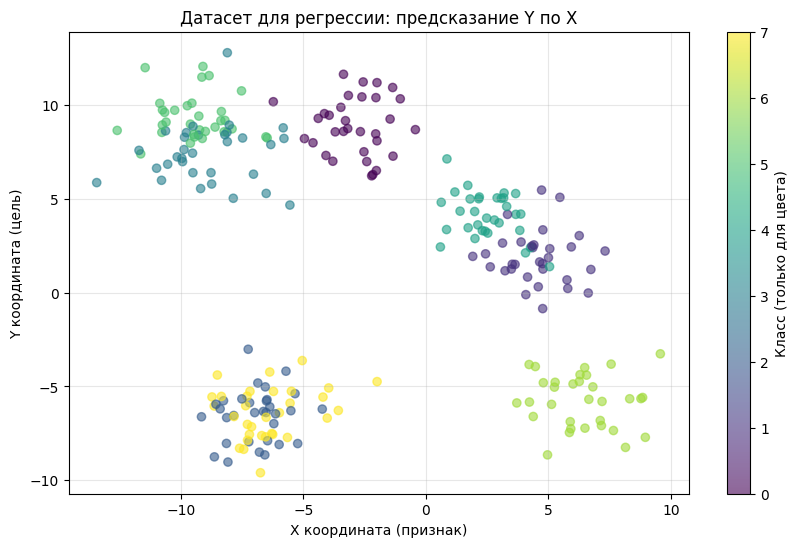

Размер обучающей выборки: (192, 3)
Размер тестовой выборки: (64, 3)


In [ ]:
# Создаем датасет с восемью классами
n_samples = 256 # Кол-во точек
n_features = 2 # Кол-во координат (признаков)
n_classes = 8

X, y = make_blobs( # X - матрица признаков, y - вектор классов
    n_samples=n_samples,
    n_features=n_features,
    centers=n_classes,
    cluster_std=1.42,
    random_state=42
)

n_centers = 8

# Признак: X координата
X_reg = X[:, 0:1]
# Цель: Y координата
y_reg = X[:, 1:2]

X_reg2 = X_reg**2
X_reg3 = X_reg**3
X_reg4 = X_reg**4


X_augmented = np.column_stack([X_reg, X_reg2, X_reg3])


# Масштабирование данных
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_augmented)
y_scaled = scaler_y.fit_transform(y_reg)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, y, test_size=0.25, random_state=42
)

# Визуализация датасета
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, alpha=0.6)

plt.title("Датасет для регрессии: предсказание Y по X")
plt.xlabel("X координата (признак)")
plt.ylabel("Y координата (цель)")
plt.colorbar(label='Класс (только для цвета)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

## 5. Создание модели PyTorch

In [387]:
class RegressionModel(nn.Module): # Наследуемся от nn.Module
    def __init__(self, input_dim=1, output_dim=1): # 1 входной: координата x, 1 выходной: координата y
        super(RegressionModel, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        #Пример нужно заменить на ваши слои
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),
            
            nn.Linear(256, output_dim)
        )
    
    def forward(self, x):
        x = self.network(x)

        return x

    def predict(self, x):
        """Возвращает предсказанные значения"""
        with torch.no_grad():
            log_probs = self.forward(x)
            return log_probs

model = RegressionModel(input_dim=3, output_dim=1)

print("Архитектура модели:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params}")
print(f"Обучаемых параметров: {trainable_params}")

Архитектура модели:
RegressionModel(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

Всего параметров: 132865
Обучаемых параметров: 132865


## 6. Подготовка данных для PyTorch

In [388]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Создаем DataLoader
batch_size = 1 # Размер батча
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер батча: {batch_size}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")

Размер батча: 1
Количество батчей в обучающей выборке: 192
Количество батчей в тестовой выборке: 64


## 7. Обучение модели

In [389]:
def train_model(model, train_loader, test_loader, epochs=50, learning_rate=0.01):
    """
    Обучает гибридную модель.
    """
    # Функция потерь и оптимизатор
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Для отслеживания метрик
    train_losses = []
    test_losses = []
    
    print("Начинаем обучение...")
    
    for epoch in range(epochs):
        # Режим обучения
        model.train()
        total_train_loss = 0
        
        for _, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Прямой проход
            output = model(data)
            loss = loss_function(output, target)
            
            # Обратный проход
            loss.backward()
            optimizer.step()
            
            # Считаем метрики
            total_train_loss += loss.item()
        
        # Средняя потеря и точность на обучающей выборке
        avg_train_loss = total_train_loss / len(train_loader)
        
        # Оценка на тестовой выборке
        model.eval()
        total_test_loss = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                loss = loss_function(output, target)
                total_test_loss += loss.item()
        
        # Средняя потеря и точность на тестовой выборке
        avg_test_loss = total_test_loss / len(test_loader)

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)

        clear_output(wait=True)
        print(f"Эпоха {epoch+1}/{epochs}:")
        print(f"  Обучающая выборка: loss={avg_train_loss:.6f}")
        print(f"  Тестовая выборка:  loss={avg_test_loss:.6f}")
    
    print("\nОбучение завершено!")
    
    return train_losses, test_losses

epochs = 100 # Количество эпох обучения (можно изменять)
learning_rate = 0.0003 # Скорость обучения (можно изменять)

train_losses, test_losses = train_model(
    model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
)

Эпоха 100/100:
  Обучающая выборка: loss=0.047384
  Тестовая выборка:  loss=0.050806

Обучение завершено!


## 8. Визуализация процесса обучения

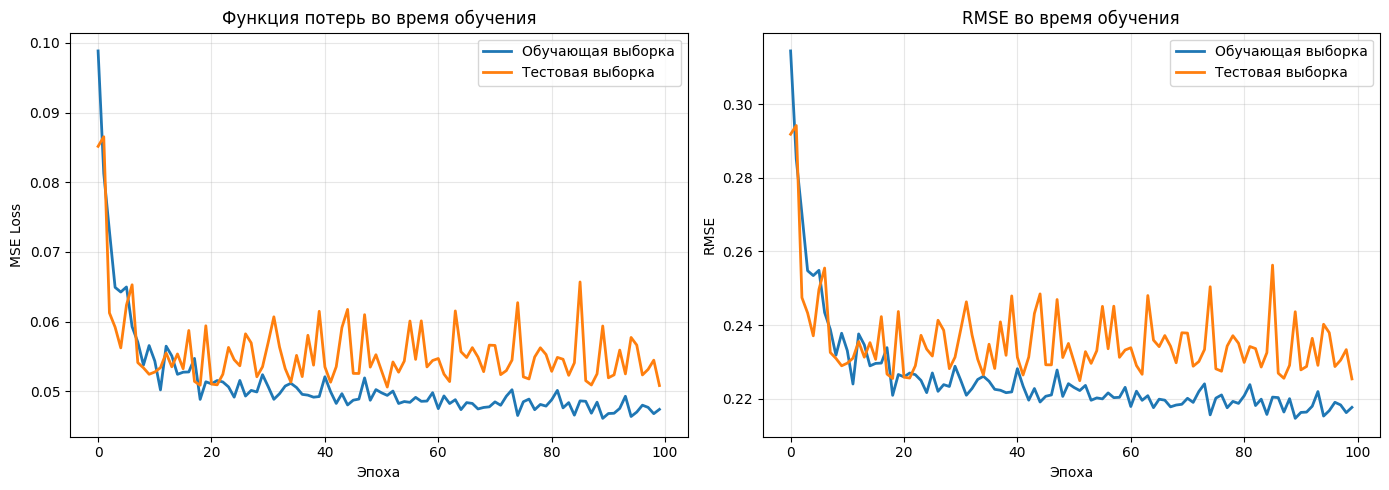

Финальная MSE на обучающей выборке: 0.047384
Финальная MSE на тестовой выборке: 0.050806
Финальная RMSE на тестовой выборке: 0.225402


In [390]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Обучающая выборка', linewidth=2)
axes[0].plot(test_losses, label='Тестовая выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Функция потерь во время обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE-график
train_rmse = [np.sqrt(l) for l in train_losses]
test_rmse = [np.sqrt(l) for l in test_losses]

axes[1].plot(train_rmse, label='Обучающая выборка', linewidth=2)
axes[1].plot(test_rmse, label='Тестовая выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE во время обучения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальная MSE на обучающей выборке: {train_losses[-1]:.6f}")
print(f"Финальная MSE на тестовой выборке: {test_losses[-1]:.6f}")
print(f"Финальная RMSE на тестовой выборке: {np.sqrt(test_losses[-1]):.6f}")

## 9. Оценка модели

Результаты регрессии:
MSE: 25.481170
RMSE: 5.047888
R²: 0.3997


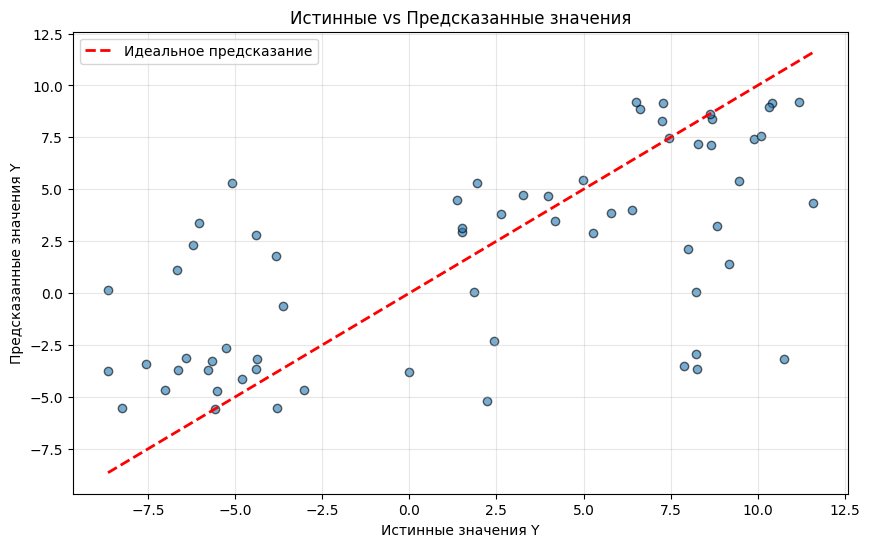

In [391]:
model.eval()

with torch.no_grad():
    y_pred = model.predict(X_test_tensor)

# Обратное масштабирование
y_pred_original = scaler_y.inverse_transform(y_pred.numpy())
y_test_original = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)

print("Результаты регрессии:")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r2:.4f}")

# График: истинные vs предсказанные
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.6, edgecolors='k')
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Истинные значения Y')
plt.ylabel('Предсказанные значения Y')
plt.title('Истинные vs Предсказанные значения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Визуализация границ решения

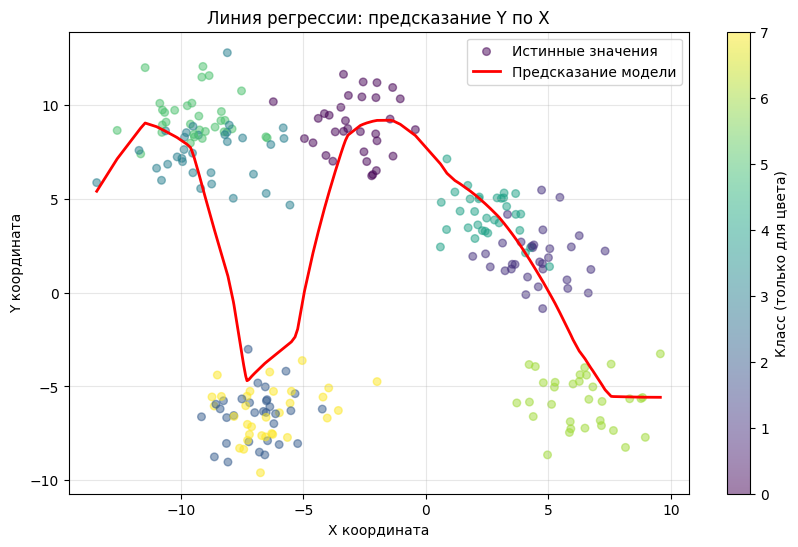

In [392]:
def plot_regression_line(model, X_scaled, y_scaled, y_class, title):
    with torch.no_grad():
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_pred = model.predict(X_tensor).numpy()

    # Обратное масштабирование
    X_original = scaler_X.inverse_transform(X_scaled)[:, 0:1]
    y_pred_original = scaler_y.inverse_transform(y_pred)
    y_true_original = scaler_y.inverse_transform(y_scaled)

    # Сортируем по X для красивой линии
    sort_idx = np.argsort(X_original.flatten())
    X_sorted = X_original[sort_idx]
    y_pred_sorted = y_pred_original[sort_idx]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(X_original, y_true_original, c=y_class, cmap='viridis', 
                alpha=0.5, s=30, label='Истинные значения')
    plt.plot(X_sorted, y_pred_sorted, 'r-', linewidth=2, label='Предсказание модели')
    plt.xlabel('X координата')
    plt.ylabel('Y координата')
    plt.title(title)
    plt.legend()
    plt.colorbar(label='Класс (только для цвета)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация на полном датасете
plot_regression_line(model, X_scaled, y_scaled, y, 
                     title="Линия регрессии: предсказание Y по X")